## 📚 Importing Required Libraries

In this step, we import all necessary Python libraries required for:

- Data manipulation (Pandas, NumPy)
- Data visualization (Matplotlib, Seaborn)
- Machine learning models (Scikit-learn)
- Time-series forecasting (Statsmodels - ARIMA)

These libraries form the foundation of the data science workflow.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## 📂 Loading the Dataset

The dataset contains retail transaction-level data.

Each row represents a single transaction with details such as:
- Transaction ID
- Date
- Store ID
- Product ID
- Quantity
- Unit Price
- Total Amount
- Customer Age

We load the dataset into a Pandas DataFrame to begin analysis.

In [46]:
df = pd.read_csv("retail_sales.csv")

df.head()

,transaction_id,date,store_id,product_id,quantity,unit_price,total_amount,customer_age
0,1,2024-03-21,15,1075,9,181.96,1637.64,27
1,2,2024-10-05,17,1062,9,134.10,1206.90,42
2,3,2024-02-16,5,1051,6,102.68,616.08,49
3,4,2024-01-23,18,1074,9,136.04,1224.36,39
4,5,2024-03-26,6,1076,3,254.36,763.08,60


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  5000 non-null   int64  
 1   date            5000 non-null   object 
 2   store_id        5000 non-null   int64  
 3   product_id      5000 non-null   int64  
 4   quantity        5000 non-null   int64  
 5   unit_price      5000 non-null   float64
 6   total_amount    5000 non-null   float64
 7   customer_age    5000 non-null   int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 312.6+ KB


In [48]:
df.columns

Index(['transaction_id', 'date', 'store_id', 'product_id', 'quantity',
       'unit_price', 'total_amount', 'customer_age'],
      dtype='object')

## 🕒 Converting Date Column

The 'date' column is currently stored as an object (string).

For time-series analysis, it must be converted into a proper datetime format.

This allows us to:
- Extract time-based features
- Perform time aggregation
- Apply forecasting models

In [49]:
df['date'] = pd.to_datetime(df['date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  5000 non-null   int64         
 1   date            5000 non-null   datetime64[ns]
 2   store_id        5000 non-null   int64         
 3   product_id      5000 non-null   int64         
 4   quantity        5000 non-null   int64         
 5   unit_price      5000 non-null   float64       
 6   total_amount    5000 non-null   float64       
 7   customer_age    5000 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(5)
memory usage: 312.6 KB


In [50]:
daily_sales = df.groupby('date')['total_amount'].sum().reset_index()

daily_sales.head()

,date,total_amount
0,2024-01-01,30780.00
1,2024-01-02,22916.82
2,2024-01-03,19202.14
3,2024-01-04,16028.52
4,2024-01-05,16506.51


## 📊 Aggregating Transaction Data into Daily Sales

The dataset contains transaction-level records.

Since forecasting is performed at a daily level, we:

- Group data by 'date'
- Sum the 'total_amount' column
- Create a new dataset containing daily total sales

This transforms raw transactions into a time-series format.

In [51]:
daily_sales.rename(columns={'total_amount': 'sales'}, inplace=True)

daily_sales.head()

,date,sales
0,2024-01-01,30780.00
1,2024-01-02,22916.82
2,2024-01-03,19202.14
3,2024-01-04,16028.52
4,2024-01-05,16506.51


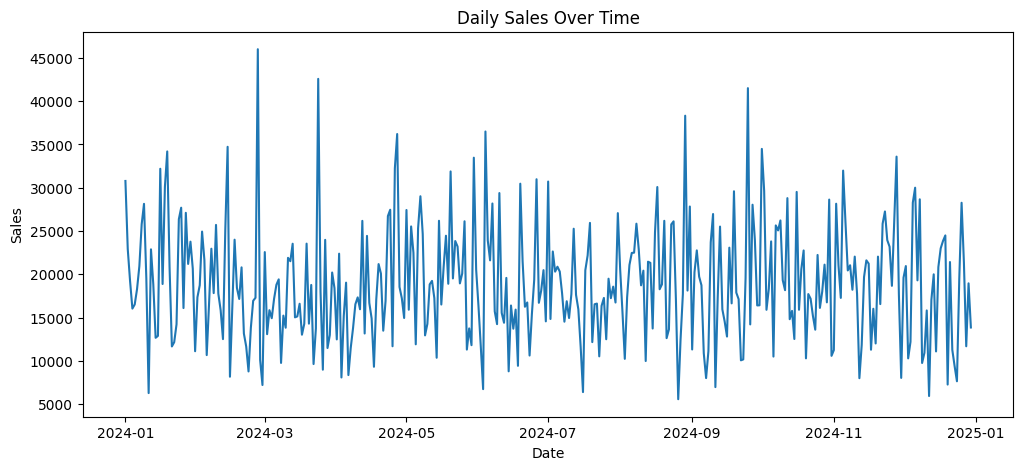

In [52]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales['date'], daily_sales['sales'])
plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

## ⚙ Feature Engineering

To help machine learning models understand time patterns, we extract:

- Year
- Month
- Day
- Day of Week

These features allow regression models to learn temporal relationships in the data.

In [53]:
daily_sales['year'] = daily_sales['date'].dt.year
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['day'] = daily_sales['date'].dt.day
daily_sales['day_of_week'] = daily_sales['date'].dt.dayofweek

daily_sales.head()

,date,sales,year,month,day,day_of_week
0,2024-01-01,30780.00,2024,1,1,0
1,2024-01-02,22916.82,2024,1,2,1
2,2024-01-03,19202.14,2024,1,3,2
3,2024-01-04,16028.52,2024,1,4,3
4,2024-01-05,16506.51,2024,1,5,4


In [54]:
# Features
X = daily_sales[['year', 'month', 'day', 'day_of_week']]

# Target
y = daily_sales['sales']

X.head()

,year,month,day,day_of_week
0,2024,1,1,0
1,2024,1,2,1
2,2024,1,3,2
3,2024,1,4,3
4,2024,1,5,4


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

Training size: 292
Testing size: 73


## 📉 Baseline Model: Linear Regression

We begin with a simple Linear Regression model to establish a baseline.

Purpose:
- Understand initial performance
- Compare advanced models against this benchmark

The model uses time-based features to predict daily sales.

In [56]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [57]:
predictions = model.predict(X_test)

predictions[:5]

array([18919.74246539, 18725.81438522, 20012.86265248, 19818.93457231,
       19625.00649214])

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 5383.042351031579
RMSE: 6600.5932180259


## 📈 Exploratory Data Analysis (EDA)

We visualize daily sales to:

- Identify trends
- Detect seasonality
- Observe fluctuations

Visualization helps us understand the behavior of sales before modeling.

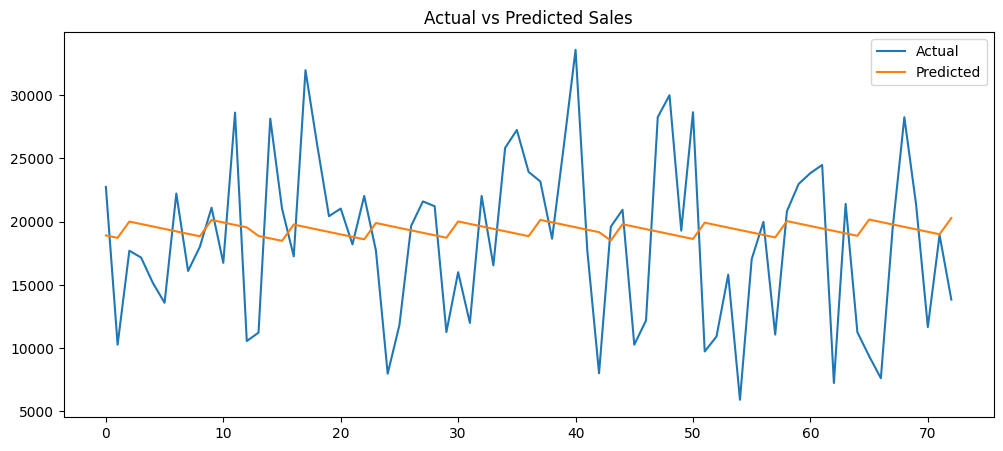

In [59]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

## 🌳 Random Forest Model

Random Forest is an ensemble learning algorithm capable of capturing nonlinear patterns.

We train this model to evaluate whether tree-based methods improve forecasting accuracy compared to Linear Regression.

In [60]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [61]:
mae_rf = mean_absolute_error(y_test, rf_predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 5956.836867123289
Random Forest RMSE: 7654.82865083947


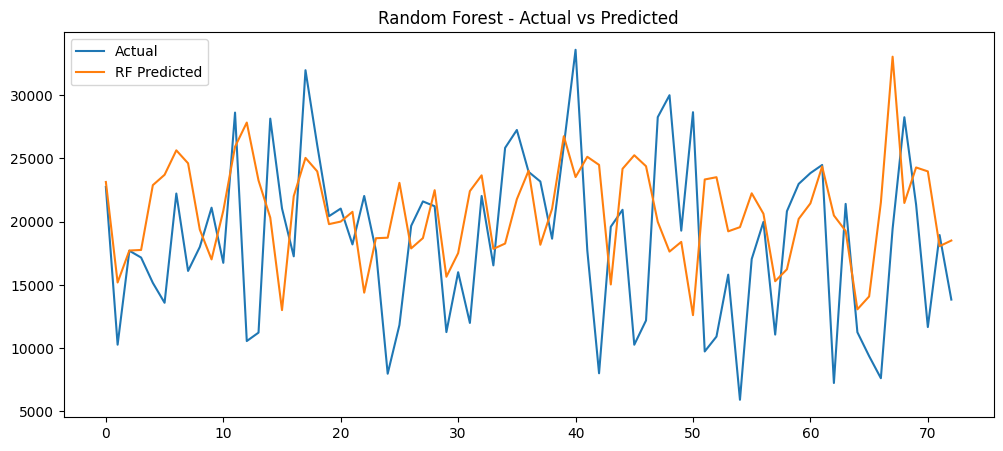

In [62]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(rf_predictions, label="RF Predicted")
plt.legend()
plt.title("Random Forest - Actual vs Predicted")
plt.show()

## ⏳ Time-Series Modeling Using ARIMA

ARIMA (AutoRegressive Integrated Moving Average) is specifically designed for time-series forecasting.

Unlike traditional ML models, ARIMA:
- Accounts for time dependency
- Handles trends
- Models sequential data effectively

We split the data into training and testing sets to evaluate performance.

In [63]:
from statsmodels.tsa.arima.model import ARIMA

sales_series = daily_sales['sales']

In [64]:
model = ARIMA(sales_series, order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  365
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -3747.504
Date:                Tue, 03 Mar 2026   AIC                           7507.009
Time:                        07:15:51   BIC                           7530.392
Sample:                             0   HQIC                          7516.302
                                - 365                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7545      0.053    -14.359      0.000      -0.858      -0.652
ar.L2         -0.7113      0.063    -11.311      0.000      -0.835      -0.588
ar.L3         -0.5080      0.062     -8.179      0.0

In [65]:
forecast = model_fit.forecast(steps=30)

forecast

,predicted_mean
365,18256.942630
366,20187.316569
367,17410.002337
368,16330.282564
369,17503.303763
370,17077.064483
371,17791.792438
372,17989.071948
373,17318.938515
374,17235.144495


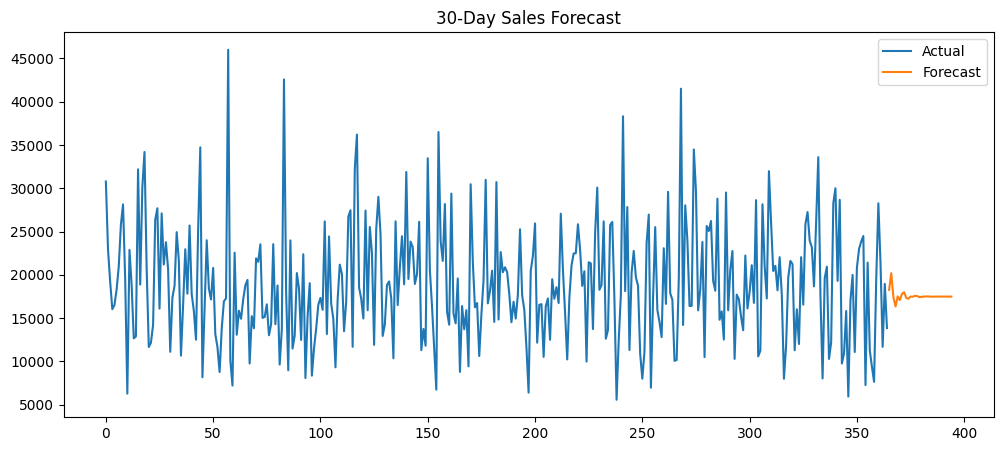

In [66]:
plt.figure(figsize=(12,5))
plt.plot(sales_series, label="Actual")
plt.plot(range(len(sales_series), len(sales_series)+30), forecast, label="Forecast")
plt.legend()
plt.title("30-Day Sales Forecast")
plt.show()

In [67]:
sales_series = daily_sales['sales']

In [68]:
daily_sales = df.groupby('date')['total_amount'].sum().reset_index()
daily_sales.rename(columns={'total_amount': 'sales'}, inplace=True)
sales_series = daily_sales['sales']

In [69]:
train_size = int(len(sales_series) * 0.8)

train = sales_series[:train_size]
test = sales_series[train_size:]

In [70]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

print("ARIMA model trained successfully")

ARIMA model trained successfully


In [71]:
forecast_test = model_fit.forecast(steps=len(test))

forecast_test.head()

,predicted_mean
292,18466.106528
293,17786.216302
294,18896.581507
295,21184.779761
296,18642.889083


## 🏆 Model Performance Comparison

We compare models using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

Lower values indicate better forecasting performance.

This comparison helps identify the most suitable model for deployment.

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(test, forecast_test)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_test))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

ARIMA MAE: 5278.469204624437
ARIMA RMSE: 6493.537624561688


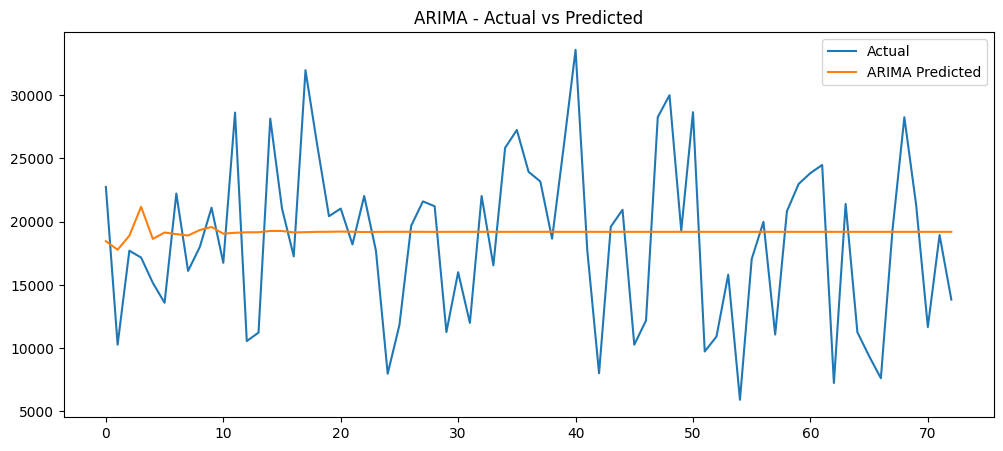

In [73]:
plt.figure(figsize=(12,5))
plt.plot(test.values, label="Actual")
plt.plot(forecast_test.values, label="ARIMA Predicted")
plt.legend()
plt.title("ARIMA - Actual vs Predicted")
plt.show()

In [74]:
final_model = ARIMA(sales_series, order=(5,1,0))
final_model_fit = final_model.fit()

future_forecast = final_model_fit.forecast(steps=30)

future_forecast

,predicted_mean
365,18256.942630
366,20187.316569
367,17410.002337
368,16330.282564
369,17503.303763
370,17077.064483
371,17791.792438
372,17989.071948
373,17318.938515
374,17235.144495


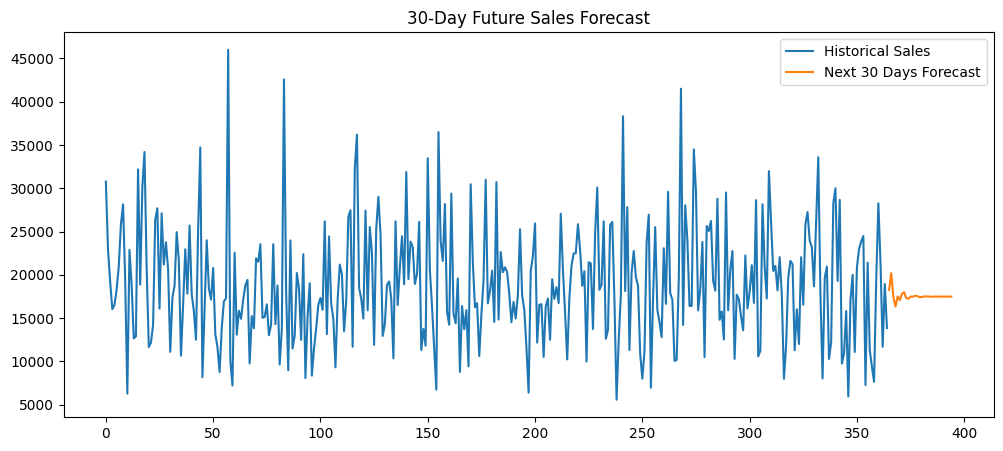

In [75]:
plt.figure(figsize=(12,5))
plt.plot(sales_series, label="Historical Sales")
plt.plot(range(len(sales_series), len(sales_series)+30), future_forecast, label="Next 30 Days Forecast")
plt.legend()
plt.title("30-Day Future Sales Forecast")
plt.show()

## ✅ Final Conclusion

- Transaction-level data was transformed into daily sales.
- Multiple models were tested.
- ARIMA achieved the best performance.
- Time-series models outperform traditional ML for sequential data.

This project demonstrates a complete end-to-end data science workflow.